# N06 · Galaxy Rotation Curves and the Discovery of Dark Matter
## Why the Andromeda galaxy spins too fast for the stars we can see

---

## Learning objectives

After this tutorial you will be able to:

1. Combine **Newton's law of gravity** with **uniform circular motion** to get the master formula $v_c(r)=\sqrt{G\,M(<r)/r}$.
2. Predict what a rotation curve *should* look like if all the mass were the **visible** matter — a **Keplerian fall-off** $v\propto 1/\sqrt{r}$ — using the **Solar System** as a warm-up.
3. Plot the **real measured rotation curve** of the Andromeda galaxy (M31) and see that it stays **flat** far beyond the visible disk.
4. Turn measured speeds into an **enclosed-mass profile** $M(<r)=v^2 r/G$ and show the mass keeps growing where there is no more light.
5. Compare the **dynamical mass** to the **visible mass** and estimate the **dark-matter fraction**.
6. Re-tell, in your own words, the chain of reasoning from *"the curve is flat"* to *"dark matter must exist."*

**Mathematics used:** algebra, square roots and one ratio — **no calculus**.
**Physics used:** Newton's law of universal gravitation and centripetal acceleration.

**Estimated time:** 2–3 hours.

---

> **How to read this notebook.** Each section states the physics in one or two lines, then asks you to do one short calculation or plot. **Before running a cell, predict what the figure will look like.** The whole argument for dark matter is built from a single formula you already know.

---

### References

- Rubin & Ford (1970), *ApJ* **159**, 379 — the spectroscopic rotation curve of M31 ([ADS](https://ui.adsabs.harvard.edu/abs/1970ApJ...159..379R/abstract)).
- Roberts & Whitehurst (1975), *ApJ* **201**, 327 — M31 stays flat in the 21 cm HI line.
- Rubin, Ford & Thonnard (1980), *ApJ* **238**, 471 — flat rotation curves for 21 spiral galaxies.
- Carignan et al. (2006), *ApJ* **641**, L109 — extended HI rotation curve of M31 to ~35 kpc ([arXiv:astro-ph/0603143](https://arxiv.org/abs/astro-ph/0603143)).
- Chemin, Carignan & Foster (2009), *ApJ* **705**, 1395 — M31 HI kinematics ([arXiv:0909.3846](https://arxiv.org/abs/0909.3846)).
- McConnachie et al. (2005), *MNRAS* **356**, 979 — distance to M31, $785$ kpc.
- Zwicky (1933), *Helv. Phys. Acta* **6**, 110 — the first hint of "dunkle Materie" in the Coma cluster.

---

## 1. Setup and the numbers we need

We measure radii in **kiloparsecs** (1 kpc ≈ 3.086 × 10¹⁶ km ≈ 3260 light-years), speeds in **km/s**, and masses in **solar masses** ($M_\odot$). In these units Newton's constant is a single number that we let `astropy` compute for us.

We will use three facts about the Andromeda galaxy (M31):

| Quantity | Value | Source |
|---|---|---|
| Distance | 785 kpc | McConnachie et al. (2005) |
| Visible mass (stars + gas) | $\approx 1.3\times10^{11}\,M_\odot$ | Carignan et al. (2006) |
| Edge of the visible light | $\approx 20$ kpc | optical disk of M31 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const

plt.rcParams.update({'figure.figsize': (8, 5), 'font.size': 12,
                     'axes.grid': True, 'grid.alpha': 0.3})

# Newton's constant in galaxy-friendly units: kpc (km/s)^2 / Msun
G = const.G.to(u.kpc * u.km**2 / u.s**2 / u.Msun).value
print(f"G = {G:.4e}  kpc (km/s)^2 / Msun")

# Three facts about the Andromeda galaxy (M31) -- these are given:
D_M31_kpc = 785.0     # distance [kpc]  (McConnachie et al. 2005)
M_visible = 1.3e11    # visible mass: stars + gas [Msun]  (Carignan et al. 2006)
R_visible = 20.0      # radius where the visible light fades [kpc]

print(f"M31 distance     = {D_M31_kpc:.0f} kpc")
print(f"M31 visible mass = {M_visible:.2e} Msun")

G = 4.3009e-06  kpc (km/s)^2 / Msun
M31 distance     = 785 kpc
M31 visible mass = 1.30e+11 Msun


---

## 2. The one formula behind everything

A star or a gas cloud on a circular orbit of radius $r$ is held in by gravity. Setting the **centripetal acceleration** equal to the **gravitational pull** from all the mass $M(<r)$ *inside* its orbit:

$$\underbrace{\frac{v^2}{r}}_{\text{circular motion}} \;=\; \underbrace{\frac{G\,M(<r)}{r^2}}_{\text{Newton's gravity}} \qquad\Longrightarrow\qquad \boxed{\,v(r)=\sqrt{\dfrac{G\,M(<r)}{r}}\,}$$

This single equation has two famous limits:

- **All the mass is already inside** (you are *outside* the matter, like a planet around the Sun): $M(<r)=$ constant, so $v\propto 1/\sqrt{r}$ — the speed **falls** with distance. This is the **Keplerian** curve.
- **The mass keeps growing** in proportion to $r$, i.e. $M(<r)\propto r$: then $v=$ constant — a **flat** curve.

So the *shape* of a rotation curve is a direct readout of *how mass is distributed*. Let's build the function $v(r)$.

In [2]:
def v_circular(M_enclosed_Msun, r_kpc):
    # Circular speed (km/s) for mass M (Msun) inside radius r (kpc).
    # Newton:  v^2 / r = G M / r^2   ->   v = sqrt(G M / r).
    return np.sqrt(G * M_enclosed_Msun / r_kpc)

# Sanity check: 1e11 Msun packed inside 10 kpc
print(f"v(1e11 Msun, 10 kpc) = {v_circular(1e11, 10):.1f} km/s")

v(1e11 Msun, 10 kpc) = 207.4 km/s


---

## 3. Warm-up: the Solar System falls off, exactly as expected

Almost all the mass of the Solar System is in the Sun. Each planet is therefore *outside* essentially all the mass, so we expect the Keplerian law $v\propto 1/\sqrt{a}$, where $a$ is the planet's distance from the Sun. Let's check it against the real planet speeds.

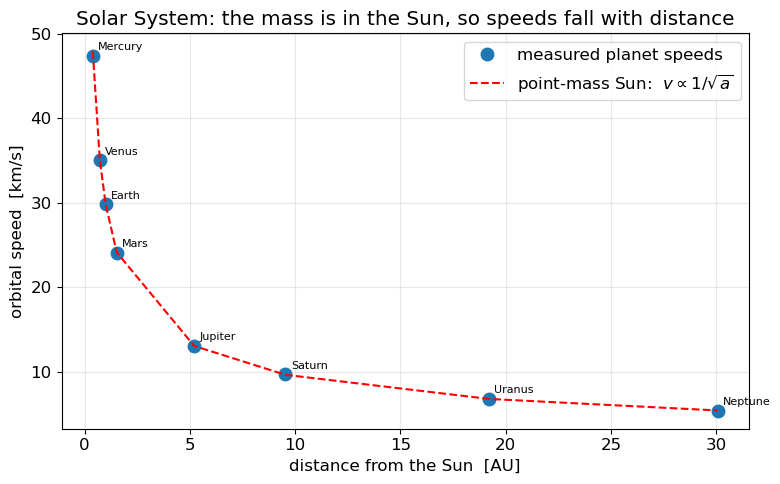

In [3]:
# Mean orbital speed (km/s) and distance from the Sun (AU) for each planet
planet   = ['Mercury','Venus','Earth','Mars','Jupiter','Saturn','Uranus','Neptune']
a_AU     = np.array([0.387, 0.723, 1.000, 1.524, 5.203, 9.537, 19.19, 30.07])
v_planet = np.array([47.4, 35.0, 29.8, 24.1, 13.1, 9.7, 6.8, 5.4])

# Point-mass Sun prediction, anchored on Earth:  v proportional to 1/sqrt(a)
v_kepler = v_planet[2] * np.sqrt(a_AU[2] / a_AU)

fig, ax = plt.subplots()
ax.plot(a_AU, v_planet, 'o', ms=9, label='measured planet speeds')
ax.plot(a_AU, v_kepler, 'r--', label=r'point-mass Sun:  $v \propto 1/\sqrt{a}$')
for x, y, n in zip(a_AU, v_planet, planet):
    ax.annotate(n, (x, y), fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('distance from the Sun  [AU]')
ax.set_ylabel('orbital speed  [km/s]')
ax.set_title('Solar System: the mass is in the Sun, so speeds fall with distance')
ax.legend()
plt.tight_layout(); plt.show()

---

## 4. The data: how fast does Andromeda spin?

Astronomers measure the rotation speed of M31 from the **Doppler shift** of light along the galaxy's major axis — first from glowing gas in the optical (Rubin & Ford 1970), then far out using the **21 cm radio line of neutral hydrogen (HI)**, which extends well beyond the stars (Carignan et al. 2006).

The values below are representative numbers read from those published curves. Plot them and look at the **outer part**: is it falling, or flat?

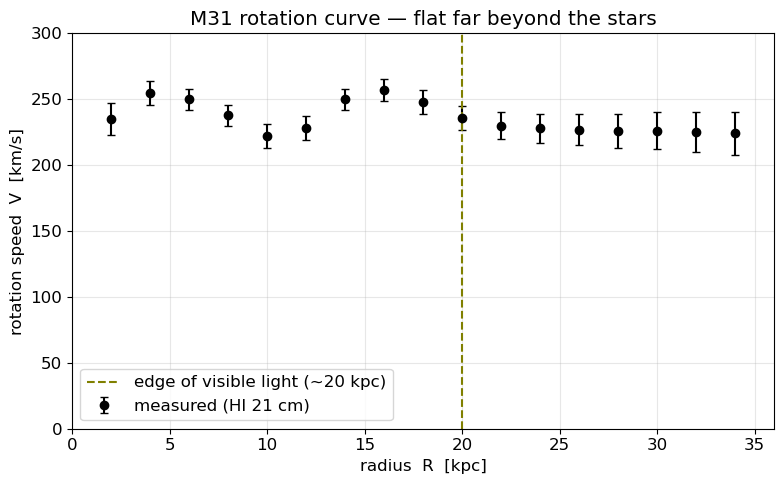

In [4]:
# Representative HI rotation curve of M31 (Andromeda).
# Read from the published curves of Carignan et al. (2006), Chemin et al. (2009)
# and Corbelli et al. (2010). Approximate values, for teaching.
R_kpc = np.array([  2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,  26,  28,  30,  32,  34])
V_kms = np.array([235, 255, 250, 238, 222, 228, 250, 257, 248, 236, 230, 228, 227, 226, 226, 225, 224])
V_err = np.array([ 12,   9,   8,   8,   9,   9,   8,   8,   9,   9,  10,  11,  12,  13,  14,  15,  16])

fig, ax = plt.subplots()
ax.errorbar(R_kpc, V_kms, yerr=V_err, fmt='ko', capsize=3, label='measured (HI 21 cm)')
ax.axvline(R_visible, color='olive', ls='--', label=f'edge of visible light (~{R_visible:.0f} kpc)')
ax.set_xlim(0, 36); ax.set_ylim(0, 300)
ax.set_xlabel('radius  R  [kpc]')
ax.set_ylabel('rotation speed  V  [km/s]')
ax.set_title('M31 rotation curve — flat far beyond the stars')
ax.legend()
plt.tight_layout(); plt.show()

---

## 5. What the visible matter predicts

The stars and gas of M31 essentially run out by about 20 kpc. **If that visible matter were all the mass there is**, then beyond 20 kpc we are *outside* the galaxy's mass — just like a planet outside the Sun — and the rotation speed should drop off as $v\propto 1/\sqrt{r}$.

Let's overplot that prediction on the data and compare.

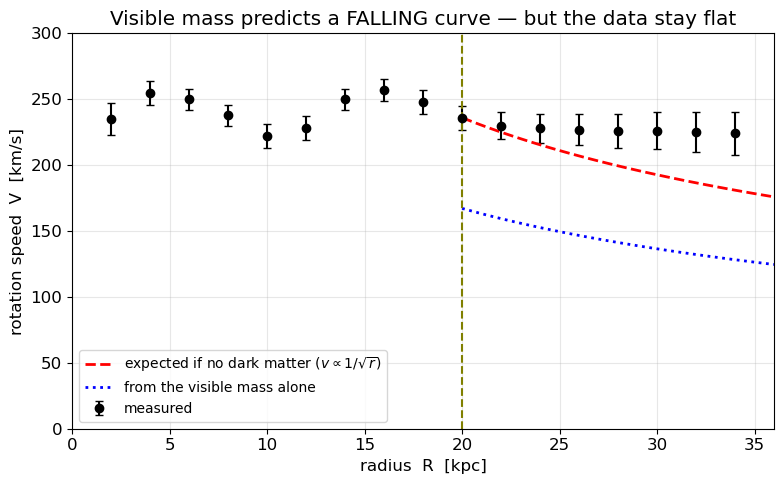

At 34 kpc:  measured ~ 224 km/s,  Keplerian prediction ~ 181 km/s


In [5]:
# Anchor the Keplerian fall-off on the observed speed at the visible edge:
R_smooth  = np.linspace(R_visible, 36, 100)
i_edge    = np.argmin(np.abs(R_kpc - R_visible))      # data point nearest the edge
V_at_edge = V_kms[i_edge]
V_kepler_outer = V_at_edge * np.sqrt(R_visible / R_smooth)

# Independent check: the speed produced by the visible mass alone
V_from_visible = v_circular(M_visible, R_smooth)

fig, ax = plt.subplots()
ax.errorbar(R_kpc, V_kms, yerr=V_err, fmt='ko', capsize=3, label='measured')
ax.plot(R_smooth, V_kepler_outer, 'r--', lw=2,
        label=r'expected if no dark matter ($v\propto 1/\sqrt{r}$)')
ax.plot(R_smooth, V_from_visible, 'b:', lw=2, label='from the visible mass alone')
ax.axvline(R_visible, color='olive', ls='--')
ax.set_xlim(0, 36); ax.set_ylim(0, 300)
ax.set_xlabel('radius  R  [kpc]')
ax.set_ylabel('rotation speed  V  [km/s]')
ax.set_title('Visible mass predicts a FALLING curve — but the data stay flat')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

V_kep_last = V_at_edge * np.sqrt(R_visible / R_kpc[-1])
print(f"At {R_kpc[-1]:.0f} kpc:  measured ~ {V_kms[-1]} km/s,"
      f"  Keplerian prediction ~ {V_kep_last:.0f} km/s")

---

## 6. Weighing the galaxy

The curve does **not** fall — it stays flat. Using our master formula in reverse, every measured speed tells us the mass inside that radius:

$$M(<r)=\frac{v^2\,r}{G}.$$

(This assumes the mass is roughly spherically arranged, which is good enough for a first estimate.) Let's see how the enclosed mass grows with radius, and compare it with the visible mass.

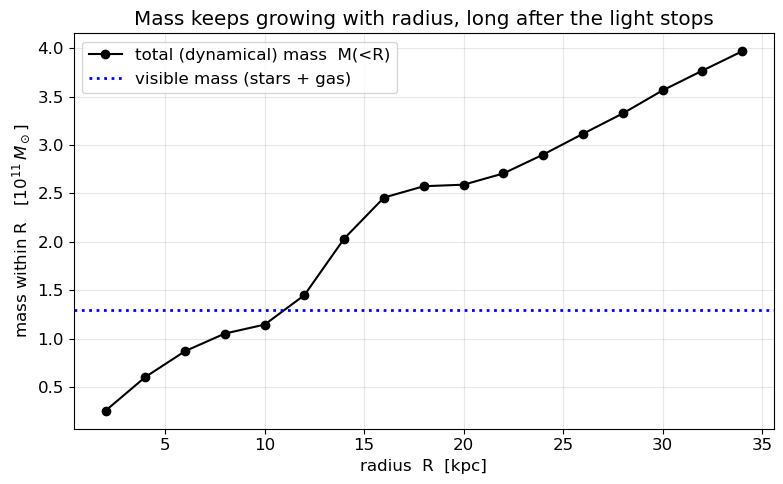

Total mass within 34 kpc : 3.97e+11 Msun
Visible mass                : 1.30e+11 Msun
Ratio (total / visible)     : 3.1


In [6]:
# Dynamical (total) mass enclosed within each radius
M_dyn = V_kms**2 * R_kpc / G        # [Msun]

fig, ax = plt.subplots()
ax.plot(R_kpc, M_dyn / 1e11, 'ko-', label='total (dynamical) mass  M(<R)')
ax.axhline(M_visible / 1e11, color='b', ls=':', lw=2, label='visible mass (stars + gas)')
ax.set_xlabel('radius  R  [kpc]')
ax.set_ylabel(r'mass within R   [$10^{11}\,M_\odot$]')
ax.set_title('Mass keeps growing with radius, long after the light stops')
ax.legend()
plt.tight_layout(); plt.show()

print(f"Total mass within {R_kpc[-1]:.0f} kpc : {M_dyn[-1]:.2e} Msun")
print(f"Visible mass                : {M_visible:.2e} Msun")
print(f"Ratio (total / visible)     : {M_dyn[-1] / M_visible:.1f}")

---

## 7. How much of Andromeda is invisible?

Once we are **outside the visible disk** ($r>20$ kpc), essentially all the stars and gas are already enclosed, so the visible mass inside $r$ is roughly constant at $M_{\rm vis}\approx1.3\times10^{11}\,M_\odot$. Anything beyond that must be **dark**:

$$f_{\rm dark}(<r)=\frac{M(<r)-M_{\rm vis}}{M(<r)}=1-\frac{M_{\rm vis}}{M(<r)}.$$

We compute it only in the outer region, where the comparison is fair.

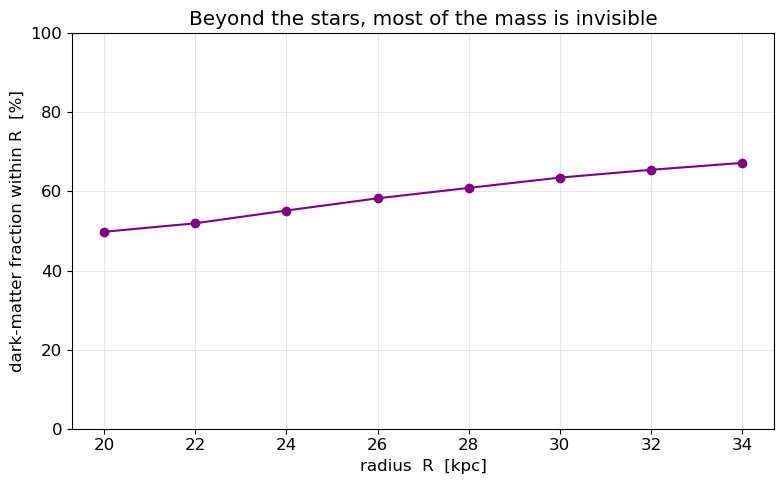

Dark-matter fraction at 20 kpc : 50 %
Dark-matter fraction at 34 kpc : 67 %


In [7]:
# Restrict to the outer region, where ~all the visible mass is already enclosed
outer  = R_kpc >= R_visible
f_dark = 1.0 - M_visible / M_dyn[outer]

fig, ax = plt.subplots()
ax.plot(R_kpc[outer], 100 * f_dark, 'o-', color='purple')
ax.set_xlabel('radius  R  [kpc]')
ax.set_ylabel('dark-matter fraction within R  [%]')
ax.set_title('Beyond the stars, most of the mass is invisible')
ax.set_ylim(0, 100)
plt.tight_layout(); plt.show()

print(f"Dark-matter fraction at {R_kpc[outer][0]:.0f} kpc : {100*f_dark[0]:.0f} %")
print(f"Dark-matter fraction at {R_kpc[-1]:.0f} kpc : {100*f_dark[-1]:.0f} %")

---

## 8. Summary — the logic in five steps

1. **Gravity + circular motion** give one formula: $v=\sqrt{G\,M(<r)/r}$.
2. If the visible matter were all the mass, the curve would **fall** beyond the stars ($v\propto1/\sqrt{r}$).
3. The measured curve of M31 stays **flat** out to ~35 kpc.
4. A flat curve means $M(<r)\propto r$ — **mass keeps piling up where there is no light**.
5. Comparing total to visible mass, **at least half** of the mass within 35 kpc is invisible: **dark matter**.

This is exactly the reasoning that, applied to dozens of galaxies in the 1970s–80s (Rubin, Ford & Thonnard 1980), turned dark matter from a curiosity into one of the central puzzles of physics.

**Caveats for the curious.** Our $M=v^2r/G$ assumes spherical symmetry and ignores the detailed shape of the disk; proper mass models (e.g. Carignan et al. 2006) are more careful but reach the same conclusion. An alternative idea, **MOND**, modifies gravity instead of adding mass — but it struggles with other evidence (galaxy clusters, the cosmic microwave background, the "Bullet Cluster").

---

## 9. Exercises

**Exercise 1 — Extrapolate.** Suppose the rotation curve stayed flat at $v=226$ km/s all the way out to $r=50$ kpc. Use $M=v^2r/G$ to estimate the enclosed mass there. How many times the visible mass is it?

**Exercise 2 — No dark matter?** What single rotation speed would M31 have at $r=30$ kpc if its *only* mass were the visible $1.3\times10^{11}\,M_\odot$? Use `v_circular`. Compare with the measured value (~226 km/s).

**Exercise 3 — Your own galaxy.** The Milky Way rotates at about $v\approx220$ km/s near the Sun ($r\approx8.2$ kpc). Estimate the mass of the Milky Way inside the Sun's orbit. (Bonus: look up the Milky Way's stellar mass and decide whether *it* needs dark matter too.)

In [8]:
# Exercise 1
M_50 = 226.0**2 * 50.0 / G
print(f"Ex1: mass within 50 kpc  = {M_50:.2e} Msun  = {M_50/M_visible:.1f} x visible")

# Exercise 2
v_novis = v_circular(M_visible, 30.0)
print(f"Ex2: speed at 30 kpc from visible mass only = {v_novis:.0f} km/s "
      f"(measured ~ 226 km/s)")

# Exercise 3
M_MW_in = 220.0**2 * 8.2 / G
print(f"Ex3: Milky Way mass within 8.2 kpc = {M_MW_in:.2e} Msun")

Ex1: mass within 50 kpc  = 5.94e+11 Msun  = 4.6 x visible
Ex2: speed at 30 kpc from visible mass only = 137 km/s (measured ~ 226 km/s)
Ex3: Milky Way mass within 8.2 kpc = 9.23e+10 Msun
